# FAPE, Student Performance EDA
## Education Domain, Academic Performance Analysis

**Dataset:** Student Performance, Cortez & Silva (2008), UCI ML Repository ID: 320  
**Records:** 1,044 (Math: 395, Portuguese: 649)  
**Target:** G3 final grade binarized at median (above median = 1)  
**Sensitive attributes:** sex (F=0, M=1), age  
**Domain:** Education  

EDA covering demographic distributions, academic performance patterns, family background effects, and educational fairness analysis across two subjects.

**Key finding:** Sex performance gap reverses between subjects, males outperform females in math, females outperform males in Portuguese.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from student_loader import load_student_performance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

os.makedirs('../figures/eda', exist_ok=True)

SEX_LABELS = {0: 'Female', 1: 'Male'}
SUBJECT_COLORS = {'Math': 'steelblue', 'Portuguese': 'coral'}
print('Imports complete')

Imports complete


In [2]:
datasets = load_student_performance()

math_df = pd.concat([datasets['math']['X'], datasets['math']['y']], axis=1)
math_df.columns = list(datasets['math']['X'].columns) + ['label']

por_df = pd.concat([datasets['portuguese']['X'], datasets['portuguese']['y']], axis=1)
por_df.columns = list(datasets['portuguese']['X'].columns) + ['label']

print(f'Math: {len(math_df)} records | Positive rate: {math_df["label"].mean():.1%}')
print(f'Portuguese: {len(por_df)} records | Positive rate: {por_df["label"].mean():.1%}')
print(f'Total: {len(math_df) + len(por_df)} records')

  Downloaded: student-mat (395 rows), student-por (649 rows)
  OK: student_math: 395 rows | 30 features | positive rate: 0.410 | median grade: 11.0
  OK: student_portuguese: 649 rows | 30 features | positive rate: 0.425 | median grade: 12.0
Math: 395 records | Positive rate: 41.0%
Portuguese: 649 records | Positive rate: 42.5%
Total: 1044 records


## 1. Label Distribution, Math vs Portuguese

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    counts = df['label'].value_counts().sort_index()
    pcts = df['label'].value_counts(normalize=True).sort_index()
    bars = ax.bar(['Below Median', 'Above Median'], counts.values,
                  color=['#d9534f', '#5cb85c'], edgecolor='black', linewidth=0.5)
    for bar, val, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({pct:.1%})', ha='center', fontsize=10)
    ax.set_title(f'{subject}, Label Distribution', fontsize=13)
    ax.set_ylabel('Number of Students')
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.suptitle('Student Performance Label Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x500 with 2 Axes>

## 2. Sex Distribution and Performance Rate

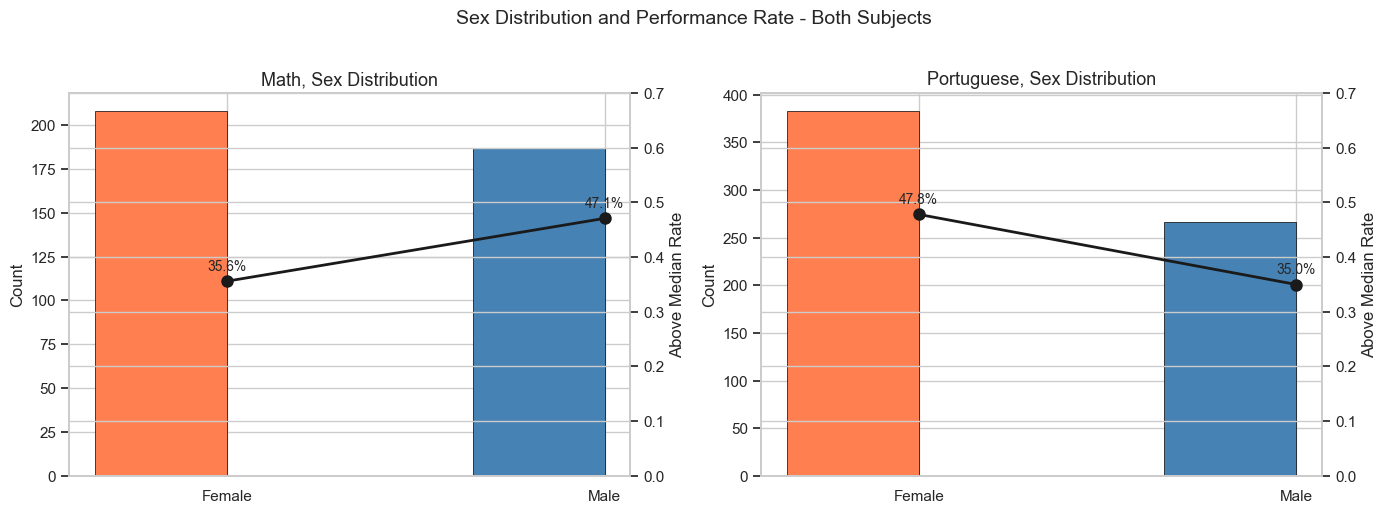

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    sex_stats = df.groupby('sex').agg(count=('label','count'), rate=('label','mean')).reset_index()
    sex_stats['sex_label'] = sex_stats['sex'].map(SEX_LABELS)
    x = range(len(sex_stats))
    width = 0.35
    bars1 = ax.bar([i - width/2 for i in x], sex_stats['count'], width,
                   color=['coral','steelblue'], edgecolor='black', linewidth=0.5, label='Count')
    ax2 = ax.twinx()
    ax2.plot(x, sex_stats['rate'], 'ko-', linewidth=2, markersize=8, label='Performance rate')
    ax.set_xticks(list(x))
    ax.set_xticklabels(sex_stats['sex_label'])
    ax.set_title(f'{subject}, Sex Distribution', fontsize=13)
    ax.set_ylabel('Count')
    ax2.set_ylabel('Above Median Rate')
    ax2.set_ylim(0, 0.7)
    for i, (_, row) in enumerate(sex_stats.iterrows()):
        ax2.text(i, row['rate'] + 0.02, f'{row["rate"]:.1%}', ha='center', fontsize=10)

plt.suptitle('Sex Distribution and Performance Rate - Both Subjects', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Sex Performance Gap Reversal, Math vs Portuguese

The most important fairness finding: sex performance gap reverses between subjects. Males outperform females in math (47.1% vs 35.6%), while females outperform males in Portuguese (47.8% vs 35.0%). A fairness intervention optimized for one subject may harm the other.

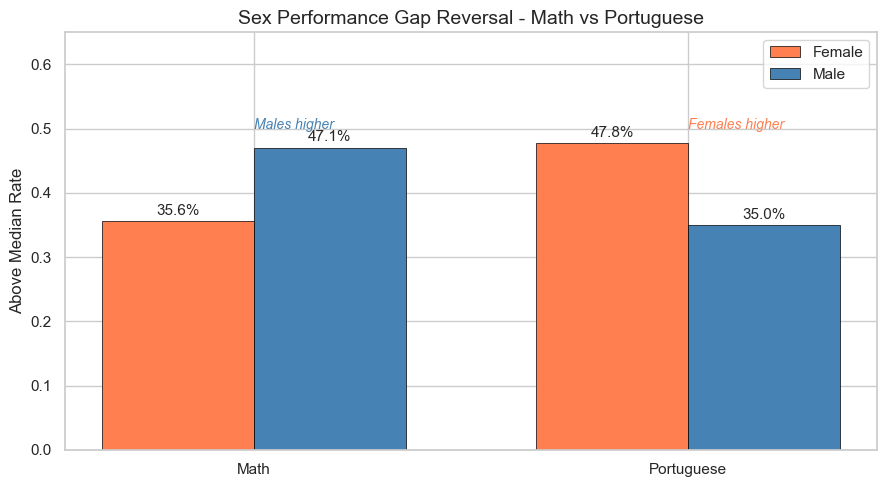

In [5]:
subjects = ['Math', 'Portuguese']
female_rates = [math_df[math_df['sex']==0]['label'].mean(),
                por_df[por_df['sex']==0]['label'].mean()]
male_rates = [math_df[math_df['sex']==1]['label'].mean(),
              por_df[por_df['sex']==1]['label'].mean()]

x = range(len(subjects))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], female_rates, width,
               label='Female', color='coral', edgecolor='black', linewidth=0.5)
bars2 = ax.bar([i + width/2 for i in x], male_rates, width,
               label='Male', color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(subjects)
ax.set_title('Sex Performance Gap Reversal - Math vs Portuguese', fontsize=14)
ax.set_ylabel('Above Median Rate')
ax.set_ylim(0, 0.65)
ax.legend()
for bar, val in zip(bars1, female_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11)
for bar, val in zip(bars2, male_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11)
ax.annotate('Males higher', xy=(0, 0.5), fontsize=10, color='steelblue', style='italic')
ax.annotate('Females higher', xy=(1, 0.5), fontsize=10, color='coral', style='italic')
plt.tight_layout()
plt.savefig('../figures/eda/student_sex_gap_reversal.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Age Distribution and Performance Rate

Note: Ages 20-22 have very small samples (n<=6), interpret with caution.

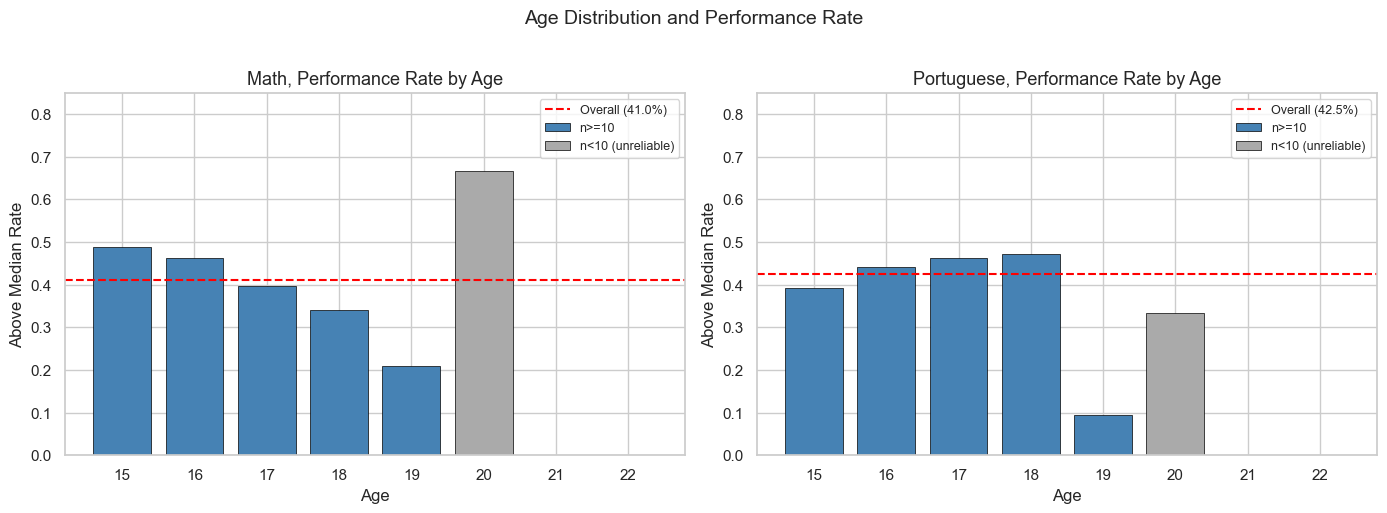

Math, ages with fewer than 10 records: 20 (n=3), 21 (n=1), 22 (n=1)
Portuguese, ages with fewer than 10 records: 20 (n=6), 21 (n=2), 22 (n=1)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    age_stats = df.groupby('age').agg(count=('label','count'), rate=('label','mean')).reset_index()
    reliable = age_stats[age_stats['count'] >= 10]
    unreliable = age_stats[age_stats['count'] < 10]
    ax.bar(reliable['age'], reliable['rate'], color='steelblue',
           edgecolor='black', linewidth=0.5, label='n>=10')
    if len(unreliable) > 0:
        ax.bar(unreliable['age'], unreliable['rate'], color='#aaaaaa',
               edgecolor='black', linewidth=0.5, label='n<10 (unreliable)')
    ax.axhline(y=df['label'].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Overall ({df["label"].mean():.1%})')
    ax.set_title(f'{subject}, Performance Rate by Age', fontsize=13)
    ax.set_xlabel('Age')
    ax.set_ylabel('Above Median Rate')
    ax.set_ylim(0, 0.85)
    ax.legend(fontsize=9)

plt.suptitle('Age Distribution and Performance Rate', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
for df, subject in [(math_df, 'Math'), (por_df, 'Portuguese')]:
    counts = df['age'].value_counts().sort_index()
    print(f'{subject}, ages with fewer than 10 records: ' + ', '.join(f'{age} (n={n})' for age, n in counts[counts < 10].items()))

## 5. Parental Education vs Performance

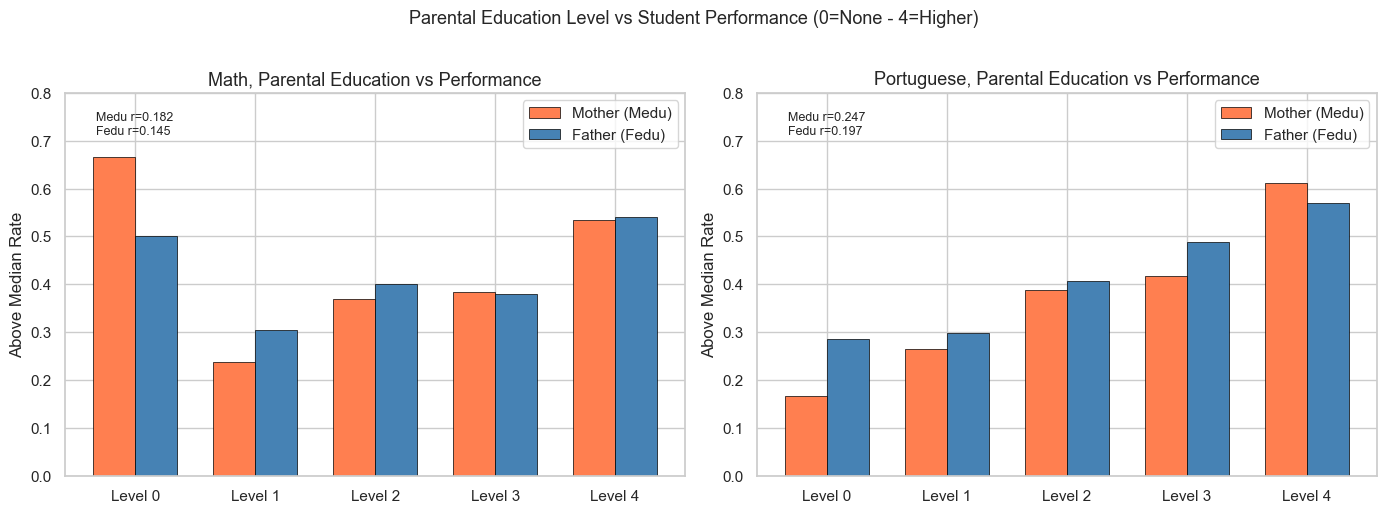

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    medu_stats = df.groupby('Medu')['label'].mean()
    fedu_stats = df.groupby('Fedu')['label'].mean()
    x = sorted(set(list(medu_stats.index) + list(fedu_stats.index)))
    width = 0.35
    ax.bar([i - width/2 for i in range(len(x))],
           [medu_stats.get(v, 0) for v in x], width,
           label='Mother (Medu)', color='coral', edgecolor='black', linewidth=0.5)
    ax.bar([i + width/2 for i in range(len(x))],
           [fedu_stats.get(v, 0) for v in x], width,
           label='Father (Fedu)', color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(x)))
    ax.set_xticklabels([f'Level {v}' for v in x])
    ax.set_title(f'{subject}, Parental Education vs Performance', fontsize=13)
    ax.set_ylabel('Above Median Rate')
    ax.set_ylim(0, 0.8)
    ax.legend()
    medu_corr = df['Medu'].corr(df['label'])
    fedu_corr = df['Fedu'].corr(df['label'])
    ax.text(0.05, 0.95, f'Medu r={medu_corr:.3f}\nFedu r={fedu_corr:.3f}',
            transform=ax.transAxes, fontsize=9, va='top')

plt.suptitle('Parental Education Level vs Student Performance (0=None - 4=Higher)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_parental_education.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Study Time vs Performance

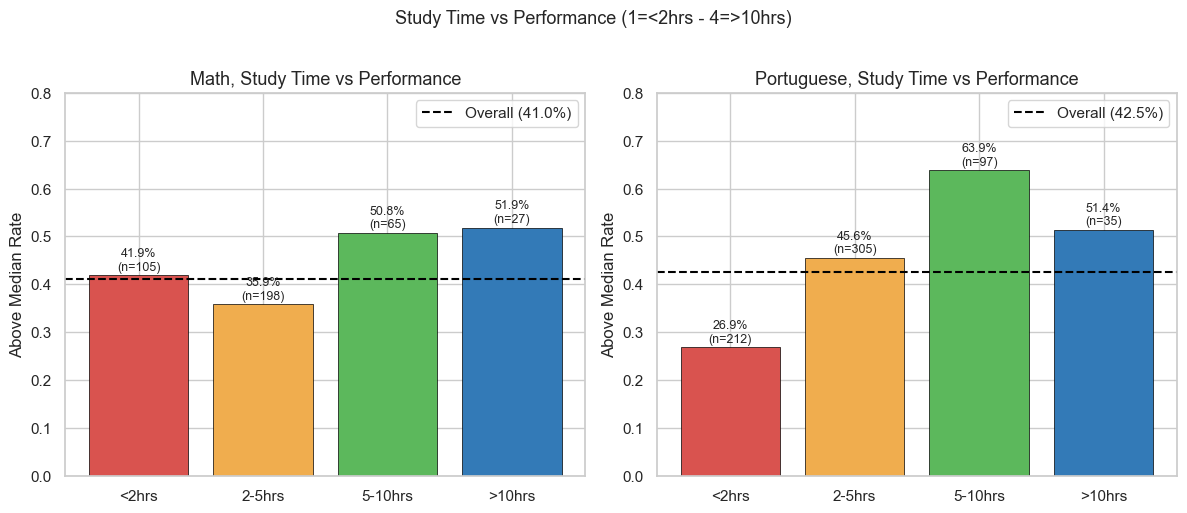

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

study_labels = {1: '<2hrs', 2: '2-5hrs', 3: '5-10hrs', 4: '>10hrs'}

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    study_stats = df.groupby('studytime').agg(count=('label','count'), rate=('label','mean')).reset_index()
    colors = ['#d9534f','#f0ad4e','#5cb85c','#337ab7']
    bars = ax.bar(range(len(study_stats)), study_stats['rate'],
                  color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Overall ({df["label"].mean():.1%})')
    ax.set_xticks(range(len(study_stats)))
    ax.set_xticklabels([study_labels.get(s, str(s)) for s in study_stats['studytime']])
    ax.set_title(f'{subject}, Study Time vs Performance', fontsize=13)
    ax.set_ylabel('Above Median Rate')
    ax.set_ylim(0, 0.8)
    ax.legend()
    for bar, (_, row) in zip(bars, study_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{row["rate"]:.1%}\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.suptitle('Study Time vs Performance (1=<2hrs - 4=>10hrs)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_study_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Past Failures vs Performance, Strongest Predictor

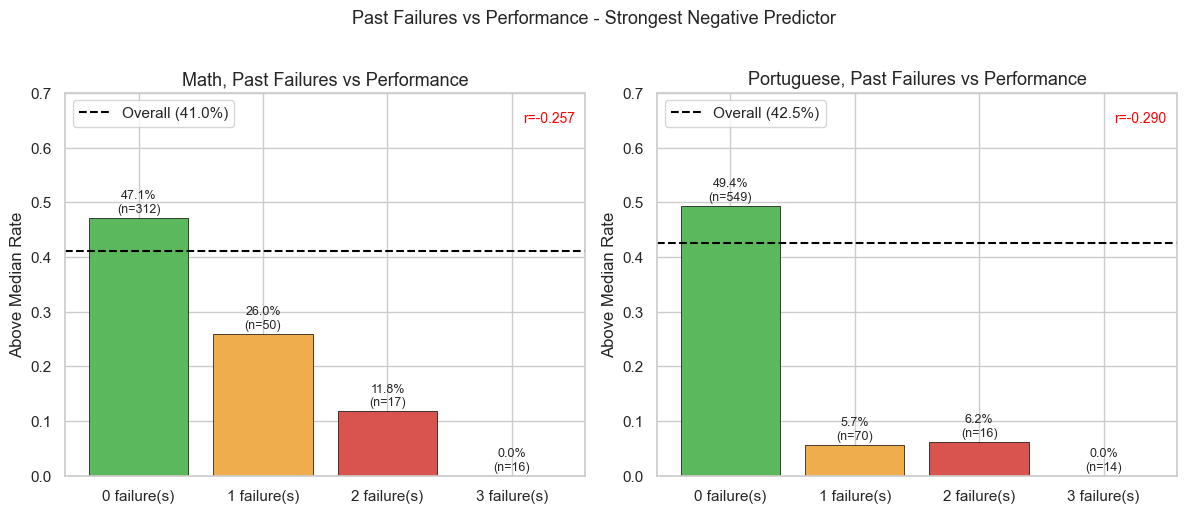

Math: 0 failures 47.1% vs 1+ failures 18.1%
Portuguese: 0 failures 49.4% vs 1+ failures 5.0%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    fail_stats = df.groupby('failures').agg(count=('label','count'), rate=('label','mean')).reset_index()
    colors = ['#5cb85c','#f0ad4e','#d9534f','#8B0000']
    bars = ax.bar(range(len(fail_stats)), fail_stats['rate'],
                  color=colors[:len(fail_stats)], edgecolor='black', linewidth=0.5)
    ax.axhline(y=df['label'].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Overall ({df["label"].mean():.1%})')
    ax.set_xticks(range(len(fail_stats)))
    ax.set_xticklabels([f'{int(f)} failure(s)' for f in fail_stats['failures']])
    ax.set_title(f'{subject}, Past Failures vs Performance', fontsize=13)
    ax.set_ylabel('Above Median Rate')
    ax.set_ylim(0, 0.7)
    ax.legend(loc='upper left')
    corr = df['failures'].corr(df['label'])
    ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes,
            fontsize=10, va='top', ha='right', color='red')
    for bar, (_, row) in zip(bars, fail_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{row["rate"]:.1%}\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.suptitle('Past Failures vs Performance - Strongest Negative Predictor', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_failures.png', dpi=150, bbox_inches='tight')
plt.show()
print('Math: 0 failures 47.1% vs 1+ failures 18.1%')
print('Portuguese: 0 failures 49.4% vs 1+ failures 5.0%')

## 8. School and Family Support Variables

**Important note:** `schoolsup` shows a paradox: students with extra school support perform worse. This is consistent with a **selection effect**, where struggling students are the ones given support; it does not show that support causes poor performance. `higher` (aspiration for higher education) shows the strongest positive effect.

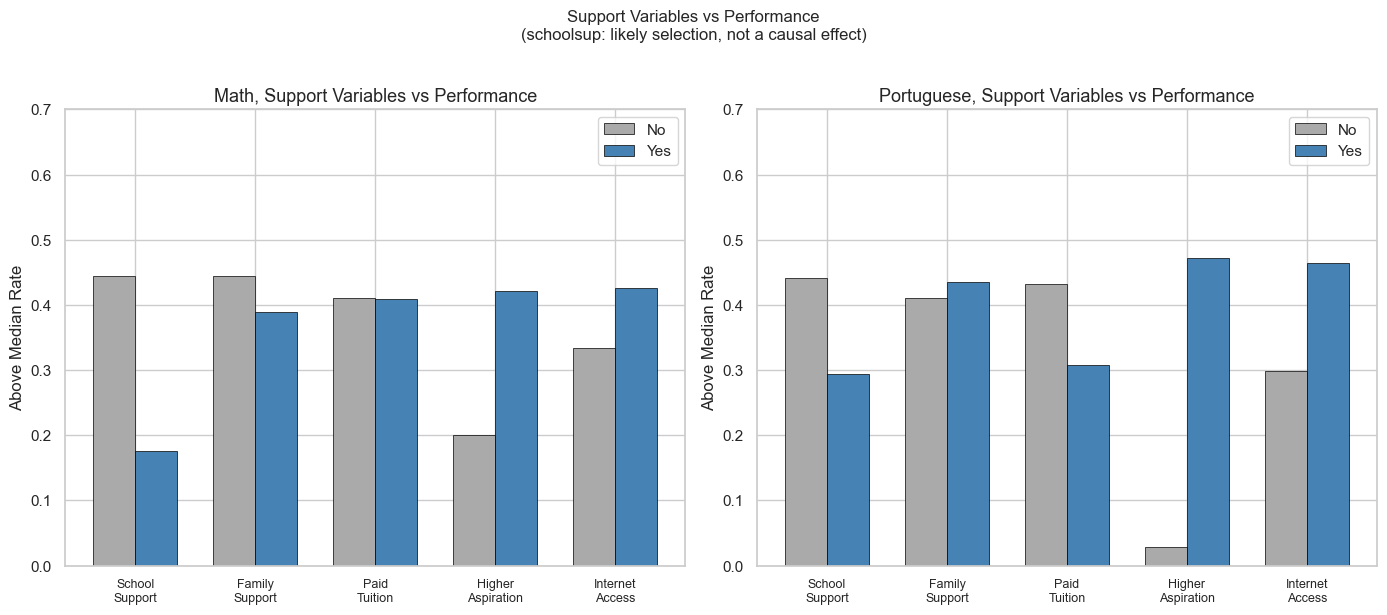

In [10]:
support_cols = ['schoolsup', 'famsup', 'paid', 'higher', 'internet']
support_labels = ['School\nSupport', 'Family\nSupport', 'Paid\nTuition', 'Higher\nAspiration', 'Internet\nAccess']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    no_rates = [df[df[col]==0]['label'].mean() for col in support_cols]
    yes_rates = [df[df[col]==1]['label'].mean() for col in support_cols]
    x = range(len(support_cols))
    width = 0.35
    ax.bar([i - width/2 for i in x], no_rates, width,
           label='No', color='#aaaaaa', edgecolor='black', linewidth=0.5)
    ax.bar([i + width/2 for i in x], yes_rates, width,
           label='Yes', color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(support_labels, fontsize=9)
    ax.set_title(f'{subject}, Support Variables vs Performance', fontsize=13)
    ax.set_ylabel('Above Median Rate')
    ax.set_ylim(0, 0.7)
    ax.legend()

plt.suptitle('Support Variables vs Performance\n(schoolsup: likely selection, not a causal effect)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_support_variables.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Absences vs Performance

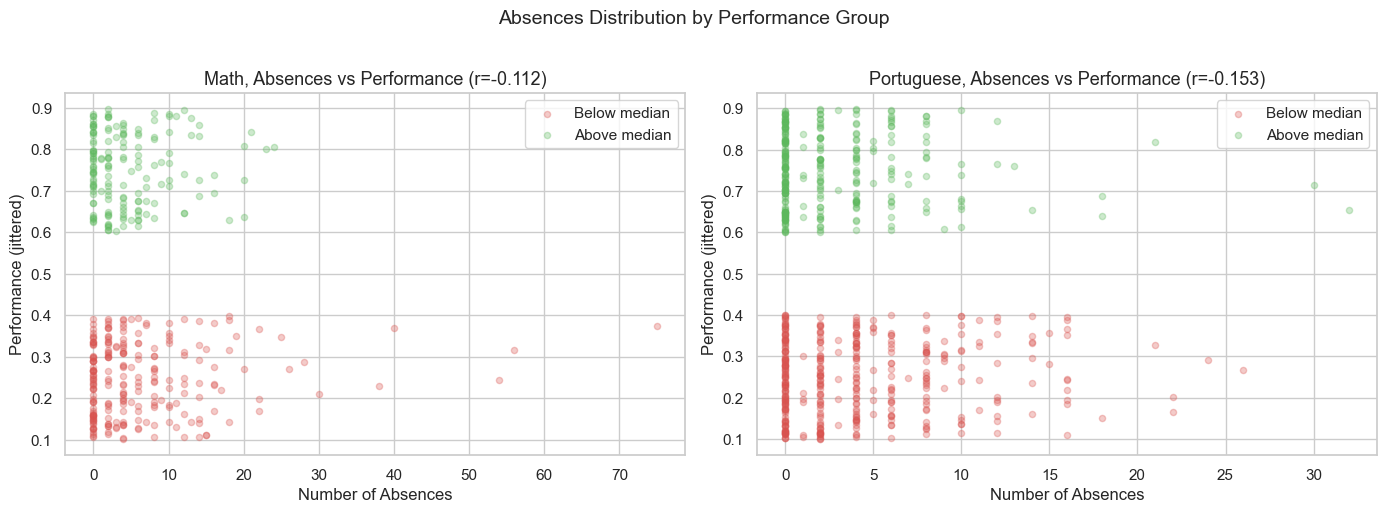

Math absences-label correlation: -0.112
Portuguese absences-label correlation: -0.153


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rng = np.random.default_rng(42)   # fixed jitter, so reruns redraw the same points

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    ax.scatter(df[df['label']==0]['absences'], 
               rng.uniform(0.1, 0.4, (df['label']==0).sum()),
               alpha=0.3, color='#d9534f', label='Below median', s=20)
    ax.scatter(df[df['label']==1]['absences'],
               rng.uniform(0.6, 0.9, (df['label']==1).sum()),
               alpha=0.3, color='#5cb85c', label='Above median', s=20)
    corr = df['absences'].corr(df['label'])
    ax.set_title(f'{subject}, Absences vs Performance (r={corr:.3f})', fontsize=13)
    ax.set_xlabel('Number of Absences')
    ax.set_ylabel('Performance (jittered)')
    ax.legend(loc='upper right')

plt.suptitle('Absences Distribution by Performance Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_absences.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Math absences-label correlation: {math_df["absences"].corr(math_df["label"]):.3f}')
print(f'Portuguese absences-label correlation: {por_df["absences"].corr(por_df["label"]):.3f}')

## 10. Alcohol Consumption vs Performance

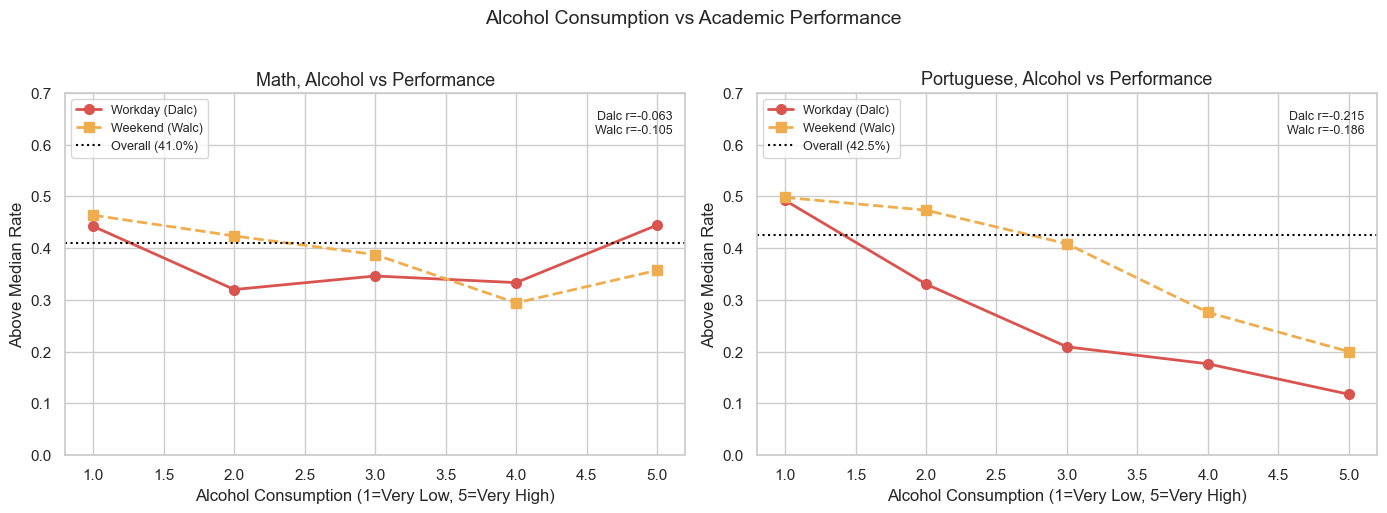

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    dalc_stats = df.groupby('Dalc')['label'].mean()
    walc_stats = df.groupby('Walc')['label'].mean()
    x_dalc = sorted(dalc_stats.index)
    x_walc = sorted(walc_stats.index)
    ax.plot(x_dalc, [dalc_stats[v] for v in x_dalc], 'o-',
            color='#d9534f', linewidth=2, markersize=7, label='Workday (Dalc)')
    ax.plot(x_walc, [walc_stats[v] for v in x_walc], 's--',
            color='#f0ad4e', linewidth=2, markersize=7, label='Weekend (Walc)')
    ax.axhline(y=df['label'].mean(), color='black', linestyle=':', linewidth=1.5,
               label=f'Overall ({df["label"].mean():.1%})')
    ax.set_title(f'{subject}, Alcohol vs Performance', fontsize=13)
    ax.set_xlabel('Alcohol Consumption (1=Very Low, 5=Very High)')
    ax.set_ylabel('Above Median Rate')
    ax.set_ylim(0, 0.7)
    ax.legend(fontsize=9, loc='upper left')
    dalc_corr = df['Dalc'].corr(df['label'])
    walc_corr = df['Walc'].corr(df['label'])
    ax.text(0.98, 0.95, f'Dalc r={dalc_corr:.3f}\nWalc r={walc_corr:.3f}',
            transform=ax.transAxes, fontsize=9, va='top', ha='right')

plt.suptitle('Alcohol Consumption vs Academic Performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_alcohol.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Intersectional Analysis, Sex × Past Failures

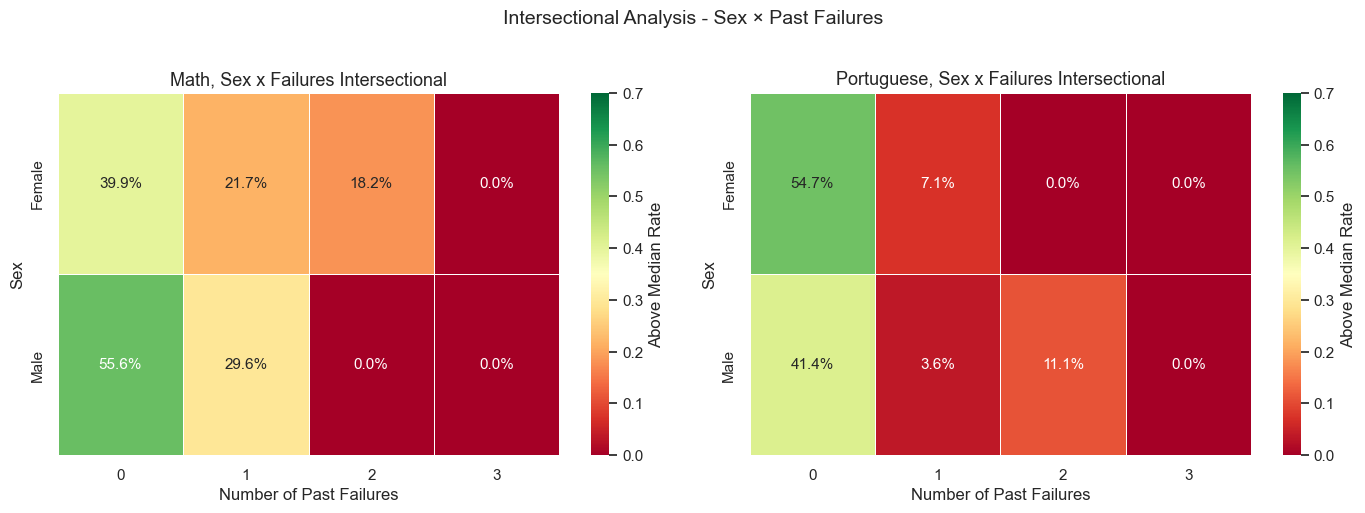

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, subject) in zip(axes, [(math_df, 'Math'), (por_df, 'Portuguese')]):
    pivot = df.groupby(['sex','failures'])['label'].mean().unstack(fill_value=np.nan)
    pivot.index = [SEX_LABELS.get(i, str(i)) for i in pivot.index]
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn',
                ax=ax, linewidths=0.5, vmin=0, vmax=0.7,
                cbar_kws={'label': 'Above Median Rate'})
    ax.set_title(f'{subject}, Sex x Failures Intersectional', fontsize=13)
    ax.set_xlabel('Number of Past Failures')
    ax.set_ylabel('Sex')

plt.suptitle('Intersectional Analysis - Sex × Past Failures', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_intersectional.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Feature Correlations with Performance Label

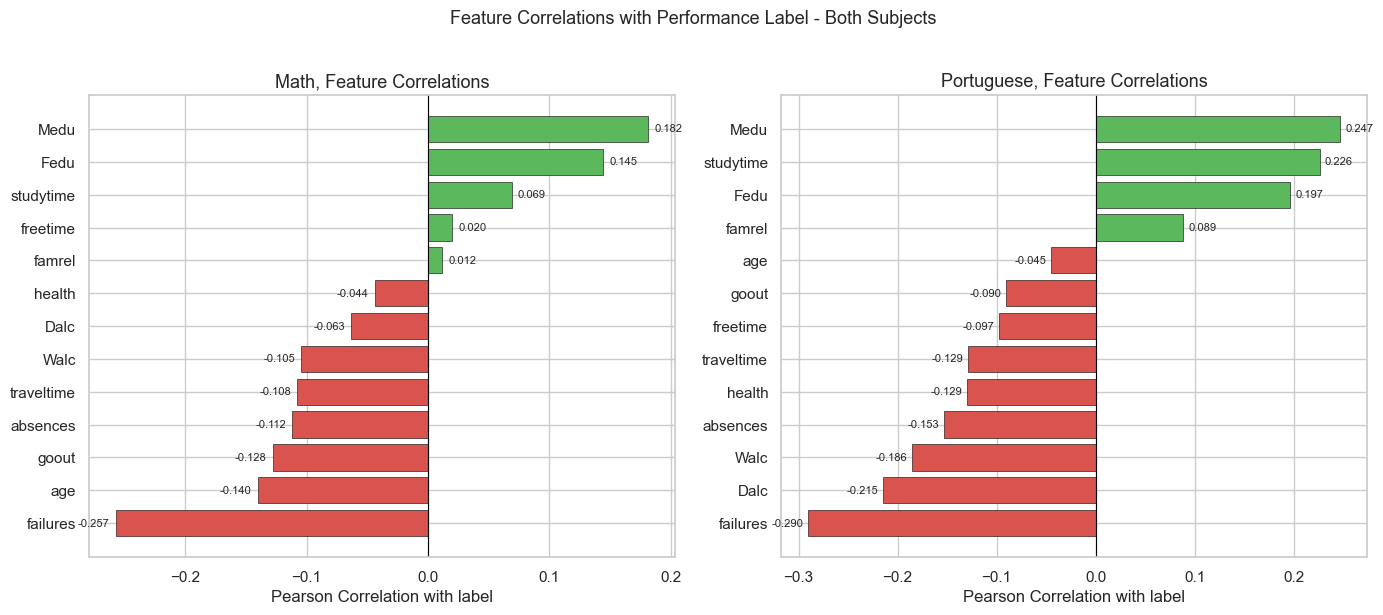

Failures is strongest negative predictor in both subjects
Math: failures r=-0.257 | Portuguese: failures r=-0.290


In [14]:
numeric_cols = ['age','Medu','Fedu','traveltime','studytime','failures',
                'famrel','freetime','goout','Dalc','Walc','health','absences']

math_corr = math_df[numeric_cols + ['label']].corr()['label'].drop('label').sort_values()
por_corr = por_df[numeric_cols + ['label']].corr()['label'].drop('label').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (corr, subject) in zip(axes, [(math_corr, 'Math'), (por_corr, 'Portuguese')]):
    colors = ['#5cb85c' if v > 0 else '#d9534f' for v in corr.values]
    ax.barh(corr.index, corr.values, color=colors, edgecolor='black', linewidth=0.4)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'{subject}, Feature Correlations', fontsize=13)
    ax.set_xlabel('Pearson Correlation with label')
    for i, (feat, val) in enumerate(corr.items()):
        offset = 0.005 if val >= 0 else -0.005
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=8)

plt.suptitle('Feature Correlations with Performance Label - Both Subjects', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/student_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Failures is strongest negative predictor in both subjects')
print(f'Math: failures r={math_corr["failures"]:.3f} | Portuguese: failures r={por_corr["failures"]:.3f}')

## 13. Key Fairness Observations

**Sex gap reversal:** Males outperform females in math (47.1% vs 35.6%, gap 11.5%). Females outperform males in Portuguese (47.8% vs 35.0%, gap 12.8%). A fairness intervention on sex tuned to one subject could work against equity in the other.

**Past failures, strongest predictor:** Zero failures → 47.1% (math) and 49.4% (Portuguese) above median. One or more failures → 18.1% (math) and 5.0% (Portuguese). Past failures correlation: math r=-0.257, Portuguese r=-0.290.

**Parental education effect:** Mother's education (Medu) is a stronger predictor than father's (Fedu) in both subjects. Higher parental education → higher student performance. This may reflect socioeconomic advantage, a structural fairness concern.

**School support paradox:** Students with extra school support perform worse. This is consistent with struggling students being the ones given support, not with support causing lower performance. This matters when reading the Stage 2 metrics.

**Small dataset caveat:** 395 and 649 records respectively. FAPE's cross-domain evaluation tests whether fairness interventions hold up on datasets this small. Ages 20-22 have very small samples (n<=6), those cells should be interpreted with caution.